<a href="https://colab.research.google.com/github/Kirieshka124/ml_basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


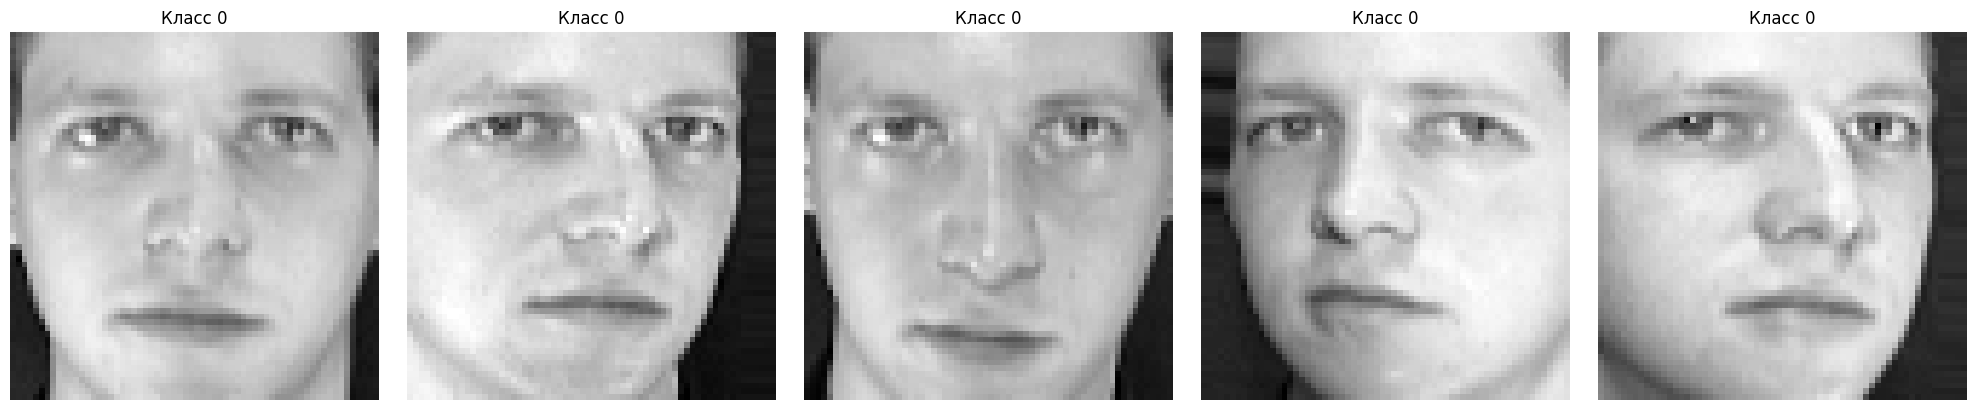

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 1/2/3
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


In [ ]:
# 4
import time
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

# Словарь для хранения результатов
results = {}

# GradientBoostingClassifier
start_time = time.time()
gbc = GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)
training_time_gbc = time.time() - start_time
y_pred_gbc = gbc.predict(X_test)
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
results['GradientBoostingClassifier'] = {'accuracy': accuracy_gbc, 'training_time': training_time_gbc}

# XGBoost
start_time = time.time()
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {'objective': 'multi:softmax', 'num_class':40, 'eval_metric': 'logloss', 'eta': 0.1, 'max_depth': 3}
num_rounds = 100
bst_xgb = xgb.train(params, dtrain, num_rounds)
training_time_xgb = time.time() - start_time
y_pred_xgb = bst_xgb.predict(dtest).astype(int)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
results['XGBoost'] = {'accuracy': accuracy_xgb, 'training_time': training_time_xgb}

# LightGBM
start_time = time.time()
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
params = {'objective': 'multiclass', 'num_class':40, 'metric': 'multi_logloss', 'learning_rate': 0.1, 'num_leaves': 31, 'verbose': -1}
num_round = 100
bst_lgb = lgb.train(params, train_data, num_round, valid_sets=[test_data])
training_time_lgb = time.time() - start_time
y_pred_lgb = np.argmax((bst_lgb.predict(X_test, num_iteration=bst_lgb.best_iteration) > 0.5).astype(int), axis=1)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
results['LightGBM'] = {'accuracy': accuracy_lgb, 'training_time': training_time_lgb}

# CatBoost
start_time = time.time()
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)
model_cb = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
model_cb.fit(train_pool)
training_time_cb = time.time() - start_time
y_pred_cb = model_cb.predict(test_pool)
accuracy_cb = accuracy_score(y_test, y_pred_cb)
results['CatBoost'] = {'accuracy': accuracy_cb, 'training_time': training_time_cb}

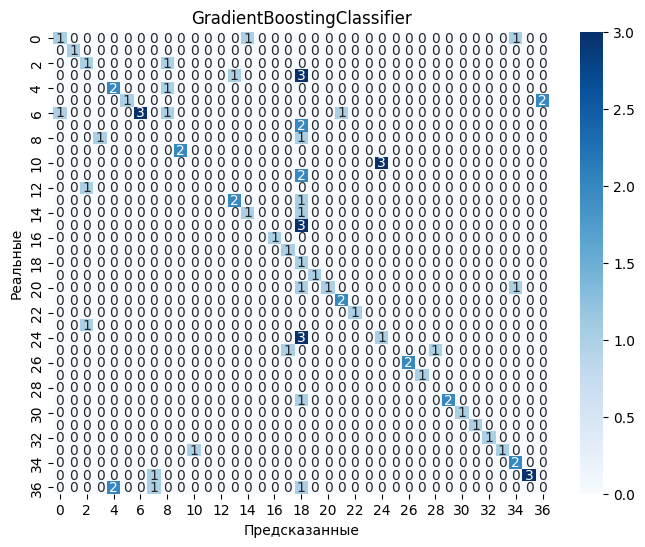

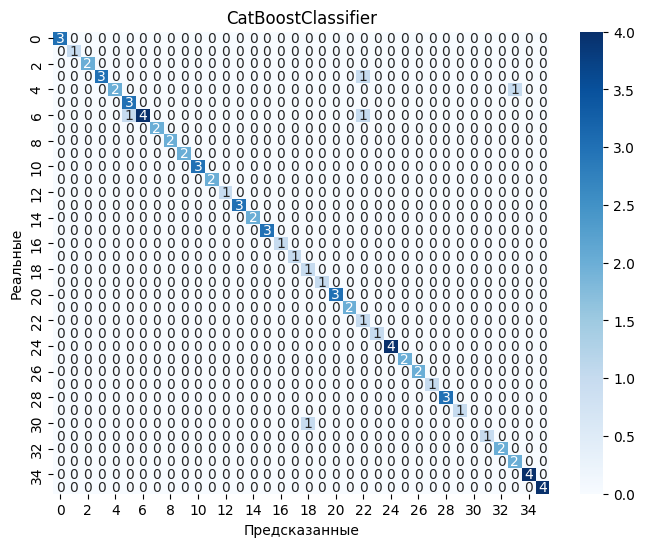

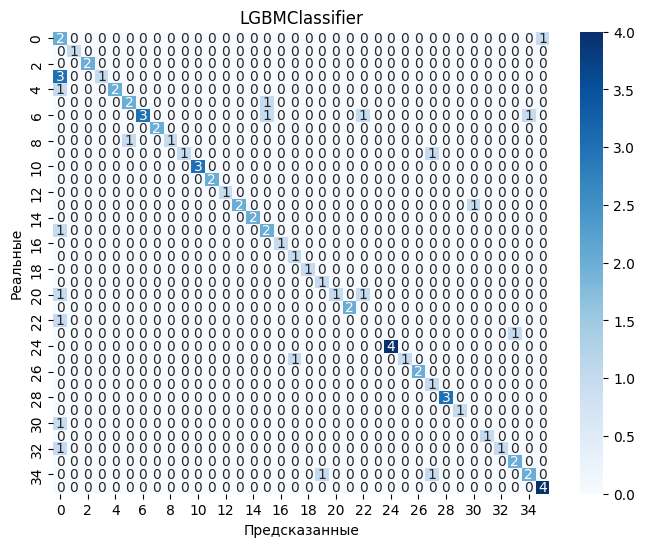

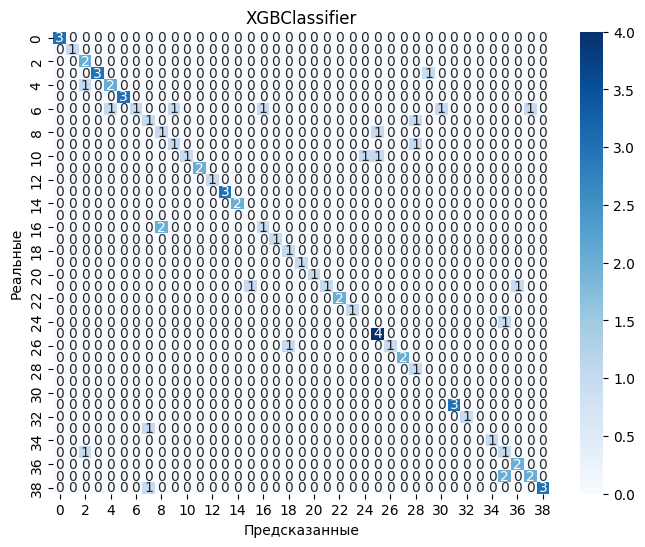

In [ ]:
# 5
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
pred = {}
pred['GradientBoostingClassifier'] = {'pred': y_pred_gbc}
pred['CatBoostClassifier'] = {'pred': y_pred_cb}
pred['LGBMClassifier'] = {'pred': y_pred_lgb}
pred['XGBClassifier'] = {'pred': y_pred_xgb}

models = list(pred.keys())
for model in models:
  cm = confusion_matrix(y_test, pred[model]['pred'])
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title(model)
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()


In [ ]:
print("Gradient")
print(classification_report(y_test, y_pred_gbc))
print("XGB")
print(classification_report(y_test, y_pred_xgb))
print("Light")
print(classification_report(y_test, y_pred_lgb))
print("Cat")
print(classification_report(y_test, y_pred_cb))

Gradient
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         1
           2       0.33      0.50      0.40         2
           3       0.00      0.00      0.00         4
           4       0.50      0.67      0.57         3
           5       1.00      0.33      0.50         3
           7       1.00      0.50      0.67         6
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.67      0.67      0.67         3
          15       0.50      0.50      0.50         2
          17       0.00      0.00      0.00         3
          18       1.00      1.00      1.00         1
          19      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

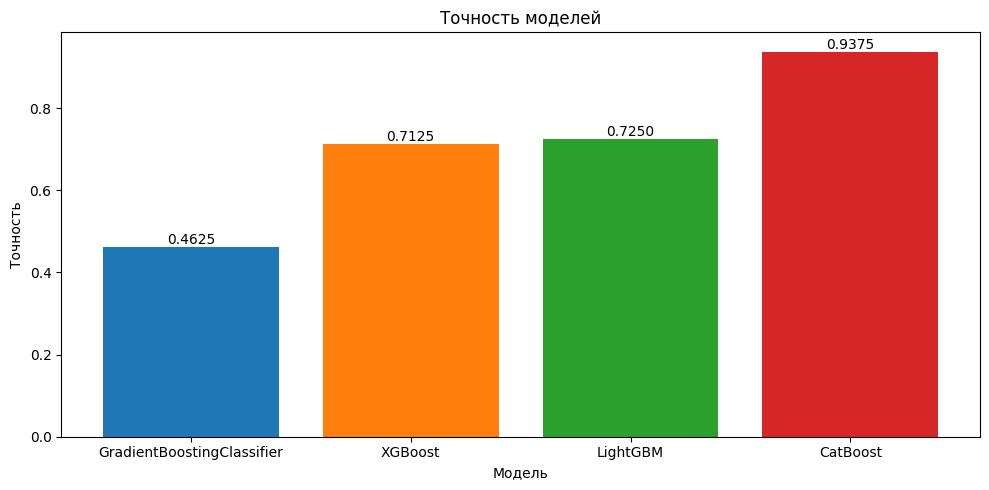

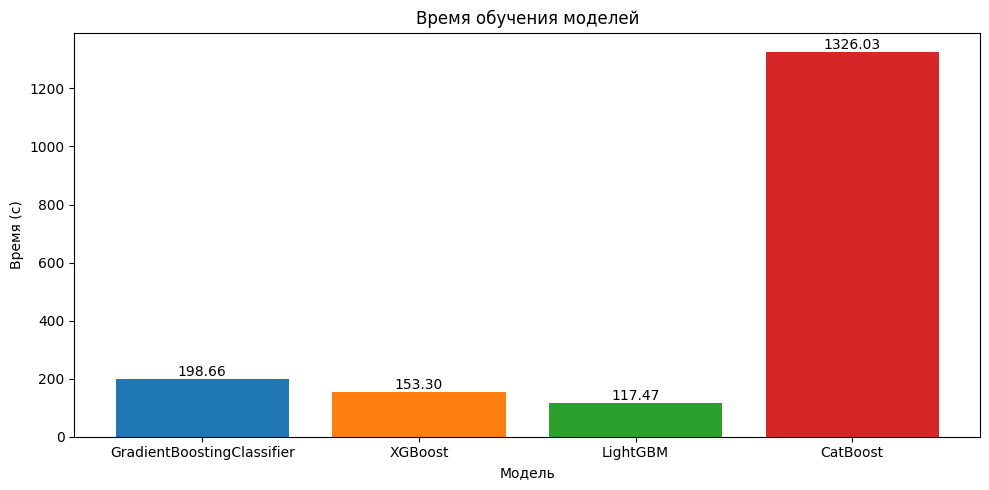

In [ ]:
# 5/6
import numpy as np


# Построение графиков
models = list(results.keys())
accuracies = [results[model]['accuracy'] for model in models]
training_times = [results[model]['training_time'] for model in models]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Цвета для столбиков

plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies, color=colors)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{accuracies[i]:.4f}', ha='center', va='bottom')
plt.title('Точность моделей')
plt.xlabel('Модель')
plt.ylabel('Точность')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.bar(models, training_times, color=colors)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{training_times[i]:.2f}', ha='center', va='bottom')
plt.title('Время обучения моделей')
plt.xlabel('Модель')
plt.ylabel('Время (с)')
plt.tight_layout()
plt.show()

№7: Лучше всего показал себя CatBoost.

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

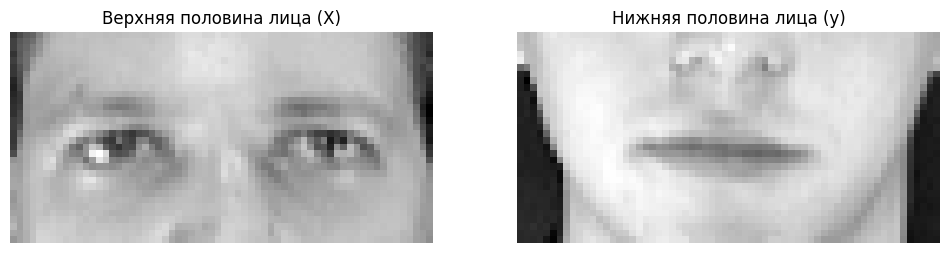

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [ ]:
# Ваш код
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 2048), (80, 2048))

In [ ]:
!pip install catboost

In [ ]:
# 4
import time
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

# Словарь для хранения результатов
results = {}
pred_test={}

# GradientBoostingRegressor (~1,5 часа)
start_time = time.time()
gbr = MultiOutputRegressor( # MultiOutputRegressor используется, т.к. в X не единичные признаки, а сразу несколько (несколько пикселей на одно лицо)
# просто .reshape(-1,1) не помогает, т.к. тогда неправильно выполняется предсказание (результатом является верхняя часть, а не нижняя)
# к сожалению, эта модель также и увеличивает время работы, достаточно намного... увы.
    GradientBoostingRegressor(n_estimators=10, random_state=42)
)
gbr.fit(X_train, y_train)
training_time_gbr = time.time() - start_time
y_pred_gbr = gbr.predict(X_test)
pred_test['GradientBoostingRegressor'] = y_pred_gbr
R2_gbr = r2_score(y_test, y_pred_gbr, multioutput='uniform_average')
results['GradientBoostingRegressor'] = {'R2': R2_gbr, 'training_time': training_time_gbr}

In [ ]:
# LightGBM (~30 мин)
from sklearn.multioutput import MultiOutputRegressor
start_time = time.time()
lgb = MultiOutputRegressor(
    lgb.LGBMRegressor(objective='regression', learning_rate=0.1, num_leaves=31, n_estimators=10, verbose=-1, random_state=42)
)
lgb.fit(X_train, y_train)
training_time_lgb = time.time() - start_time
y_pred_lgb = lgb.predict(X_test)
pred_test['LightGBM'] = y_pred_lgb
R2_lgb = r2_score(y_test, y_pred_lgb, multioutput='uniform_average')
results['LightGBM'] = {'R2': R2_lgb, 'training_time': training_time_lgb}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [ ]:
# XGBoost (~20 мин.)
start_time = time.time()
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {'objective': 'reg:squaredlogerror', 'eta': 0.1, 'max_depth': 3}
num_rounds = 10
bst_xgb = xgb.train(params, dtrain, num_rounds)
training_time_xgb = time.time() - start_time
y_pred_xgb = bst_xgb.predict(dtest)
pred_test['XGBoost'] = y_pred_xgb
R2_xgb = r2_score(y_test, y_pred_xgb)
results['XGBoost'] = {'R2': R2_xgb, 'training_time': training_time_xgb}

In [ ]:
# CatBoost (~30 мин.)
start_time = time.time()
cb = MultiOutputRegressor(
    CatBoostRegressor(iterations=10, learning_rate=0.1, depth=3, verbose=0, random_state=42)
)
cb.fit(X_train, y_train)
training_time_cb = time.time() - start_time
y_pred_cb = cb.predict(X_test)
pred_test['CatBoost'] = y_pred_cb
R2_cb = r2_score(y_test, y_pred_cb, multioutput='uniform_average')
results['CatBoost'] = {'R2': R2_cb, 'training_time': training_time_cb}

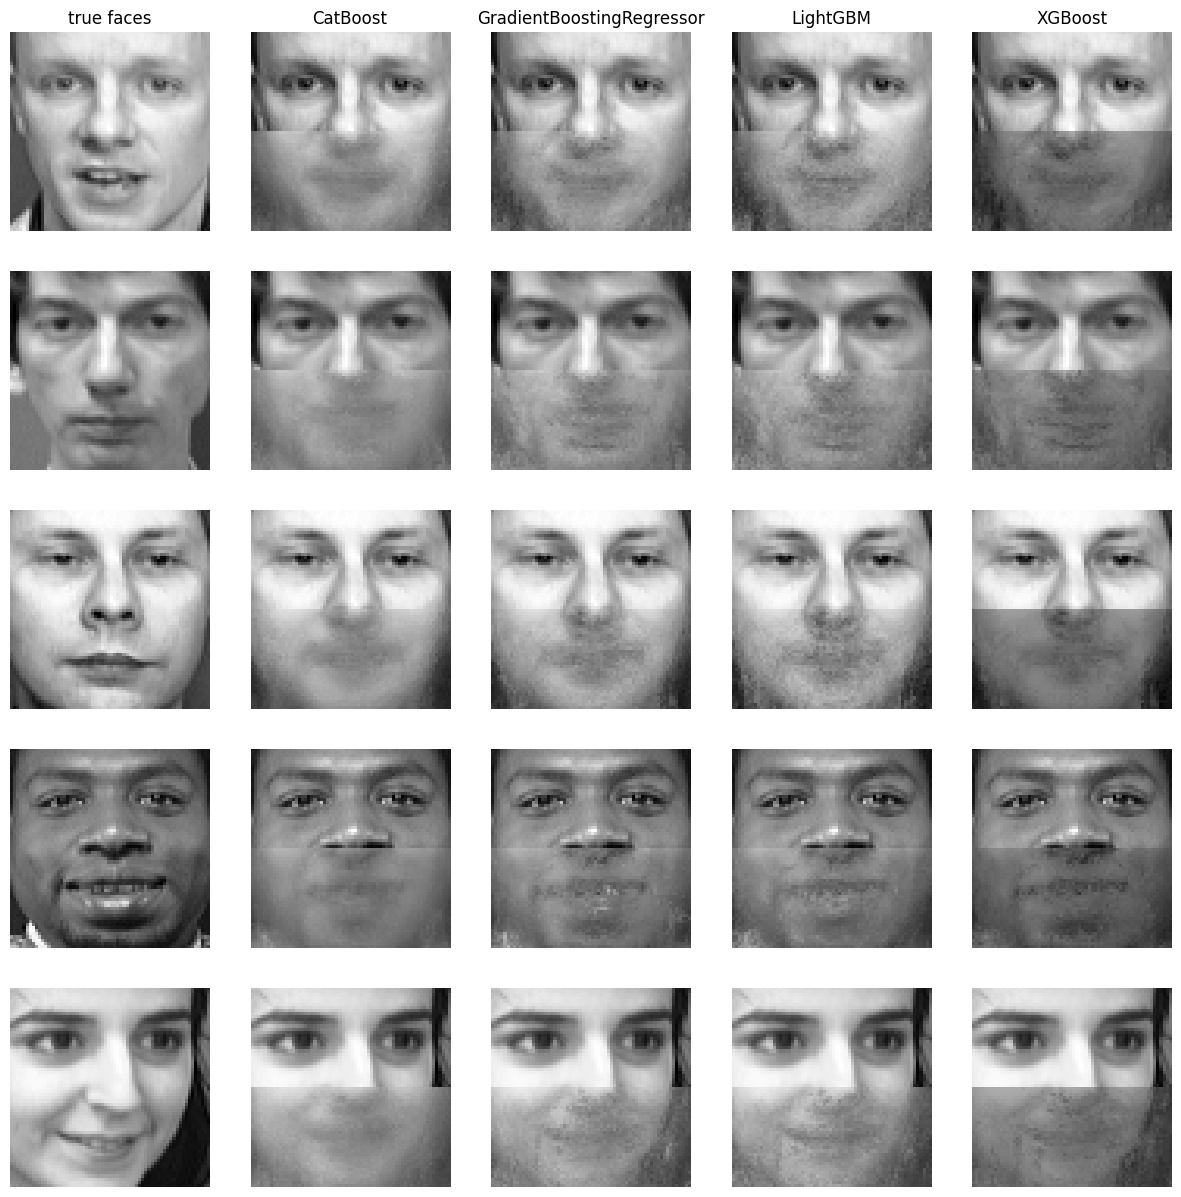

In [ ]:
ESTIMATORS = {'GradientBoostingRegressor': None,
              'XGBoost': None,
              'CatBoost': None,
              'LightGBM': None}

n_faces = 5
n_cols = 1 + len(ESTIMATORS)
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    for j, est in enumerate(sorted(ESTIMATORS)):
        if pred_test[est].shape != (80, 2048):
          pred = pred_test[est].reshape(80,2048)
        else:
          pred = pred_test[est]
        completed_face = np.hstack((X_test[i], pred[i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(
            completed_face.reshape(image_shape),
            cmap=plt.cm.gray,
            interpolation="nearest",
        )

Как было до MultiOutputRegressor и выставленным значением n_estimators = 100
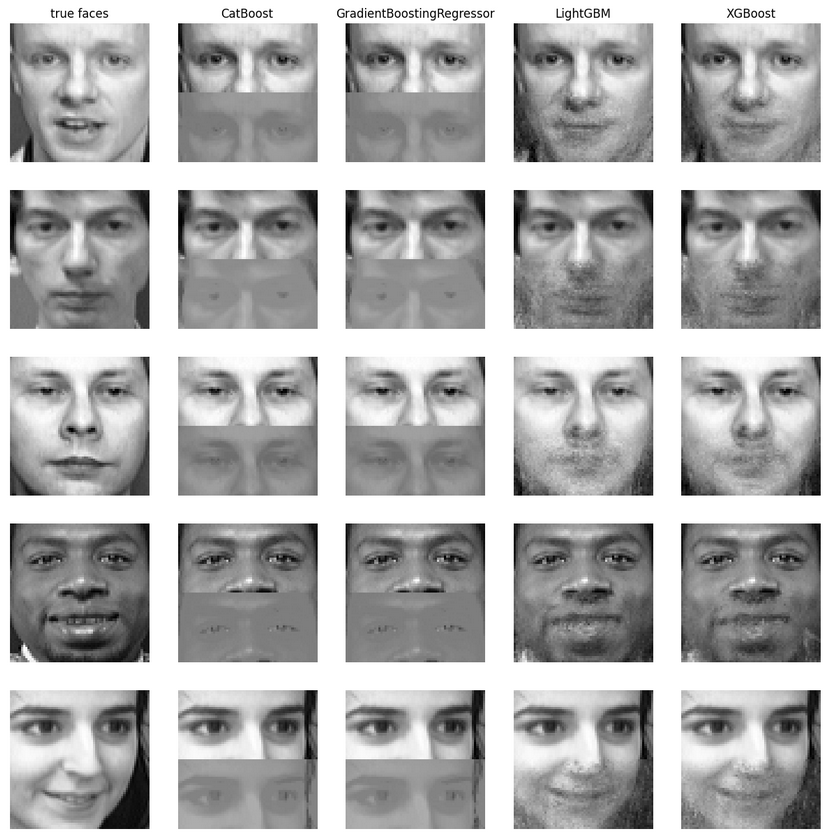

In [ ]:
from sklearn.metrics import r2_score
for i in pred_test.keys():
  if y_test.shape != pred_test[i].shape:
    print(f"R2 score ({i}): {r2_score(y_test.reshape(-1,1), pred_test[i])}")
  else:
    print(f"R2 score ({i}): {r2_score(y_test, pred_test[i])}")

R2 score (GradientBoostingRegressor): 0.4153112581702656
R2 score (LightGBM): 0.4447502257495104
R2 score (XGBoost): -0.23993028700351715
R2 score (CatBoost): 0.31900229043133793


## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


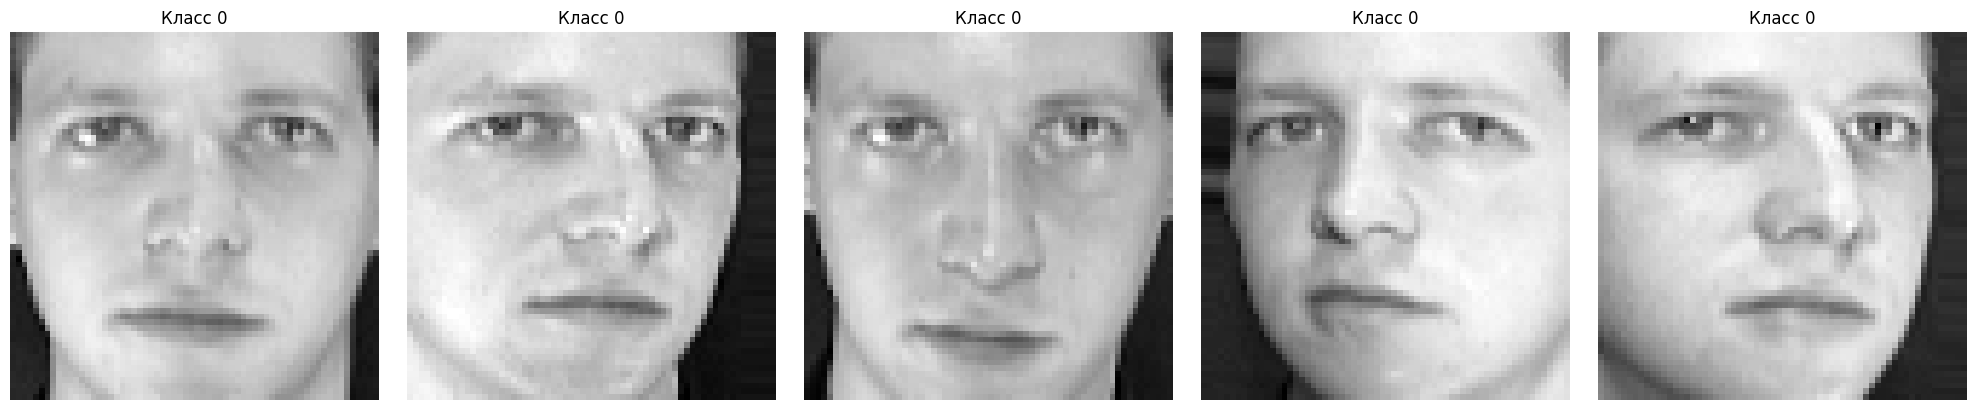

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 1/2/3
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [ ]:
# Ваш код
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(max_iter=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

In [ ]:
# Создаем ансамбль с мягким голосованием
voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)],
    voting='soft'  # Используем вероятности предсказаний
)

# Обучение ансамбля
voting_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('nb', GaussianNB())],
                 voting='soft')

In [ ]:
# Обучение каждой модели
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
nb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GaussianNB()

In [ ]:
from sklearn.metrics import accuracy_score

# Логистическая регрессия
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Точность Логистической регрессии: {acc_lr:.4f}')

# KNN
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Точность KNN: {acc_knn:.4f}')

# Дерево решений
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Точность Дерева решений: {acc_dt:.4f}')

# Наивный Байес
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Точность Наивного Байеса: {acc_nb:.4f}')

Точность Логистической регрессии: 0.9625
Точность KNN: 0.8625
Точность Дерева решений: 0.4875
Точность Наивного Байеса: 0.8375


In [ ]:
# Оценка ансамбля
y_pred_ensemble = voting_clf.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Точность Ансамбля с голосованием: {acc_ensemble:.4f}')

# Сравнение точностей
models = ['Логистическая регрессия', 'KNN', 'Дерево решений', 'Наивный Байес', 'Ансамбль VotingClassifier']
accuracies = [acc_lr, acc_knn, acc_dt, acc_nb, acc_ensemble]

Точность Ансамбля с голосованием: 0.9625


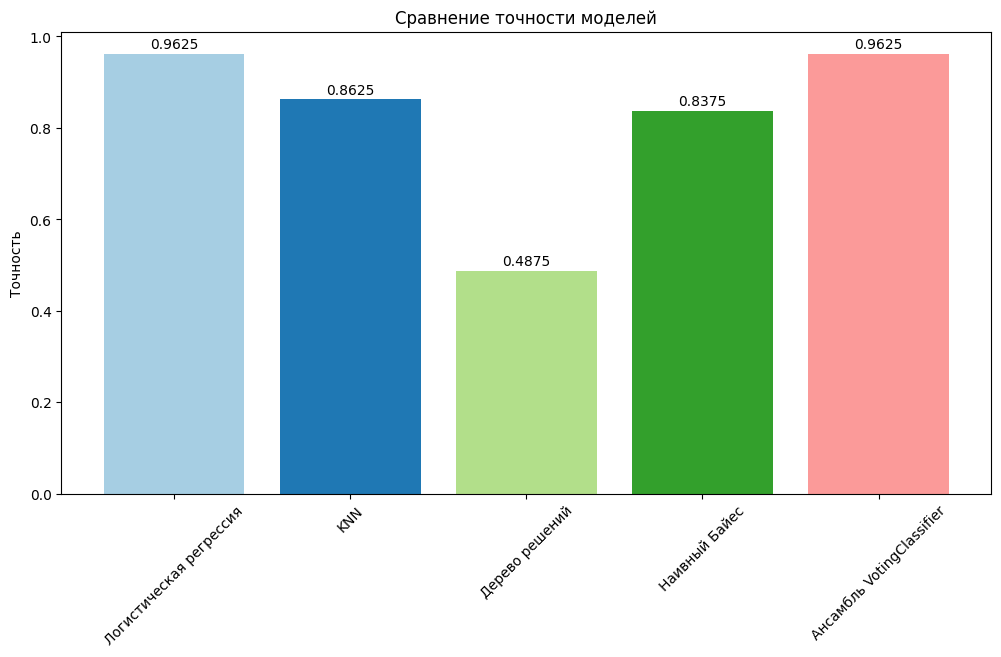

In [ ]:
# Построение столбчатой диаграммы точности моделей
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(models)), accuracies, color=plt.cm.Paired(range(len(models))))
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')

# Отображение названий моделей на оси x
plt.xticks(range(len(models)), models, rotation=45)

# Отображение значений точности над столбцами
for bar, accuracy in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{accuracy:.4f}', ha='center', va='bottom')

plt.show()

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

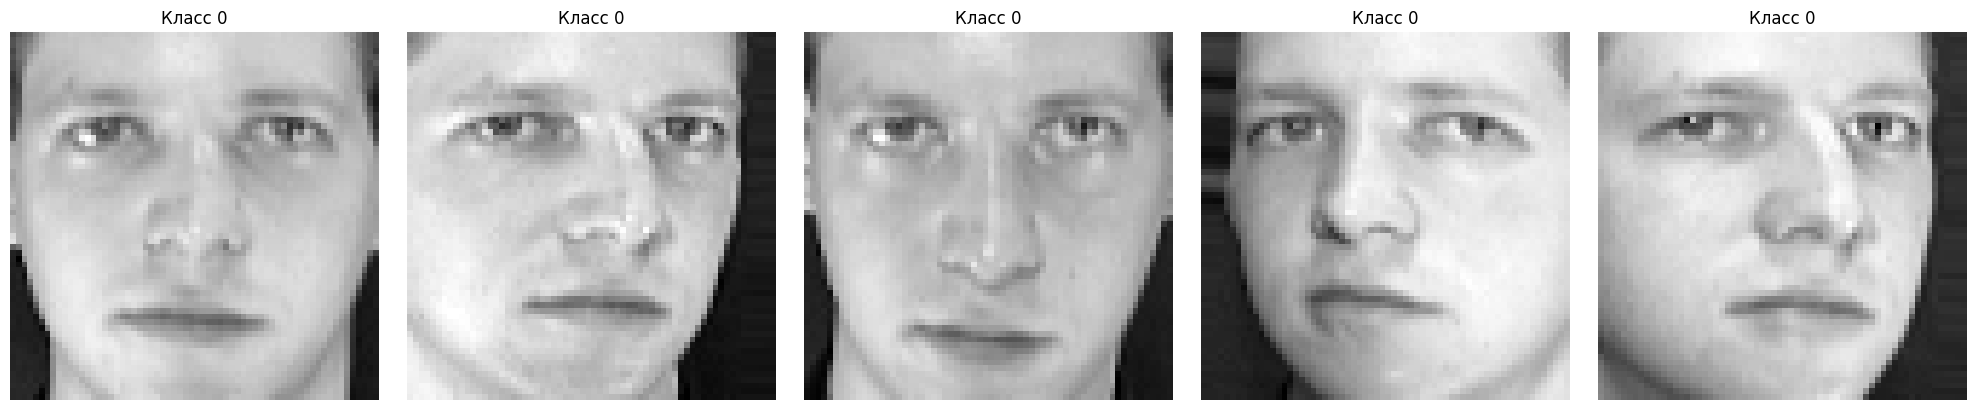

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [ ]:
# Ваш код
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold

lr = LogisticRegression(max_iter=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

# Создание регрессора стекинга
stacking_regressor = StackingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)],
    final_estimator=LogisticRegression(max_iter=100, random_state=42),
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)

In [ ]:
# Обучение классификатора стекинга
stacking_regressor.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('nb', GaussianNB())],
                   final_estimator=LogisticRegression(random_state=42))

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Оценка производительности классификатора стекинга
stacking_pred = stacking_regressor.predict(X_test)
acc_stacking = accuracy_score(y_test, stacking_pred)
print(f"Accuracy (Stacking): {acc_stacking:.4f}")
print(classification_report(y_test, stacking_pred))

Accuracy (Stacking): 0.9375
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.00         0
          17       1.00      1.00      1.00         3

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
models = []
accuracies = []

# Оценка производительности базовых моделей
for name, model in [('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)]:
    # Обучение на всей обучающей выборке
    model.fit(X_train, y_train)
    # Предсказания на тестовых данных
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    models.append(name)
    accuracies.append(acc)
    print(f"Accuracy ({name}): {acc:.4f}")
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Accuracy (lr): 0.9625
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         1
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

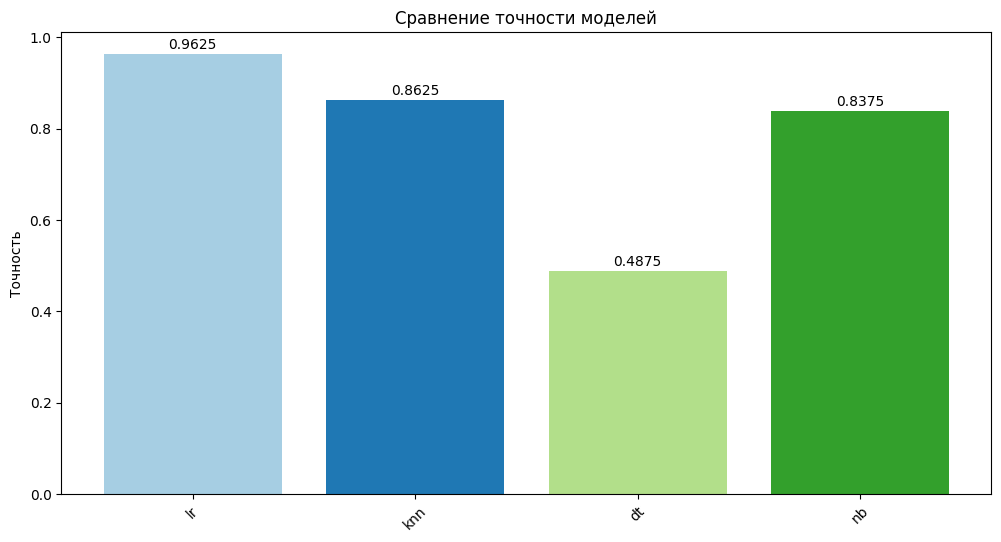

In [ ]:
# Построение столбчатой диаграммы точности моделей
plt.figure(figsize=(12, 6))

bars = plt.bar(range(len(models)), accuracies, color=plt.cm.Paired(range(len(models))))
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')

# Отображение названий моделей на оси x
plt.xticks(range(len(models)), models, rotation=45)

# Отображение значений точности над столбцами
for bar, accuracy in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{accuracy:.4f}', ha='center', va='bottom')

plt.show()